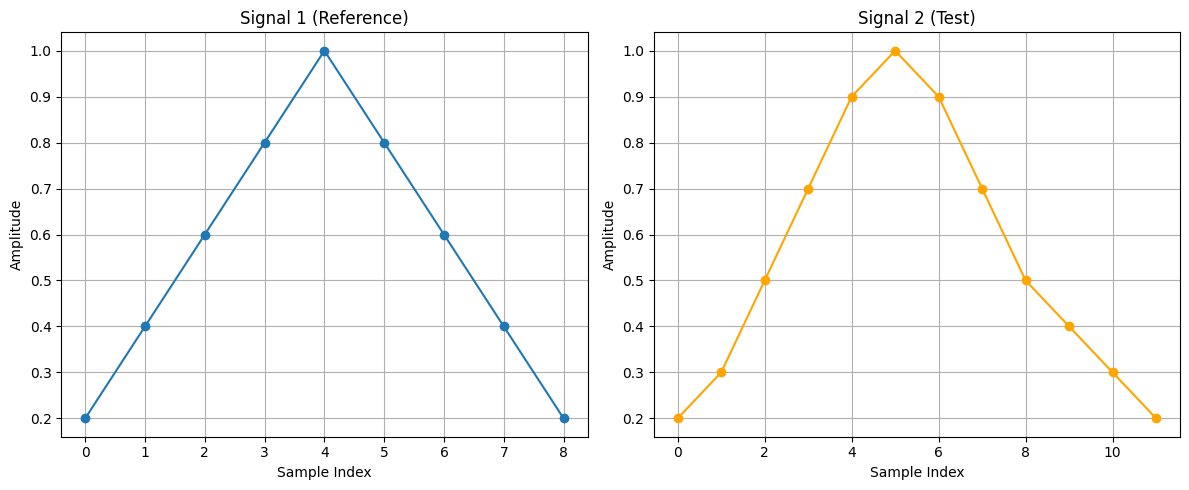

Observation:
Signal 2 is longer than Signal 1, indicating slower speech. Both have similar amplitude patterns but differ in time duration.



In [ ]:
# ---------------------------------------------------------------
# (a) Plot both speech signals to observe their differences
# ---------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define signals
signal1 = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 0.8, 0.6, 0.4, 0.2])   # Reference signal
signal2 = np.array([0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 0.9, 0.7, 0.5, 0.4, 0.3, 0.2])  # Test signal

# Plot both signals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(signal1, marker='o')
plt.title('Signal 1 (Reference)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(signal2, marker='o', color='orange')
plt.title('Signal 2 (Test)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Observation:")
print("Signal 2 is longer than Signal 1, indicating slower speech. Both have similar amplitude patterns but differ in time duration.\n")

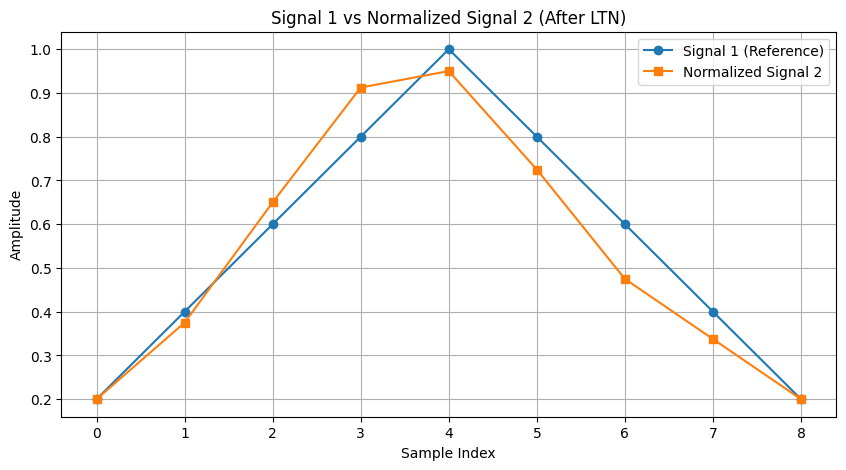

Explanation:
Signal 2 has been linearly interpolated to match the length of Signal 1. This compresses the slower speech signal to the same duration.



In [ ]:
# ---------------------------------------------------------------
# (b) Perform Linear Time Normalization (LTN)
# ---------------------------------------------------------------

len1 = len(signal1)
len2 = len(signal2)

# Create interpolation function for Signal 2
x_old = np.linspace(0, 1, len2)
f = interp1d(x_old, signal2, kind='linear')

# Resample Signal 2 to match Signal 1 length
x_new = np.linspace(0, 1, len1)
signal2_normalized = f(x_new)

# Plot after normalization
plt.figure(figsize=(10, 5))
plt.plot(signal1, marker='o', label='Signal 1 (Reference)')
plt.plot(signal2_normalized, marker='s', label='Normalized Signal 2')
plt.title('Signal 1 vs Normalized Signal 2 (After LTN)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.show()

print("Explanation:")
print("Signal 2 has been linearly interpolated to match the length of Signal 1. This compresses the slower speech signal to the same duration.\n")

In [ ]:
# ---------------------------------------------------------------
# (c) Compute the alignment between Signal 1 and Normalized Signal 2
# ---------------------------------------------------------------

alignment = signal1 - signal2_normalized
mse = np.mean(alignment ** 2)
print(f"Mean Squared Error after Linear Time Normalization: {mse:.4f}\n")

Mean Squared Error after Linear Time Normalization: 0.0048



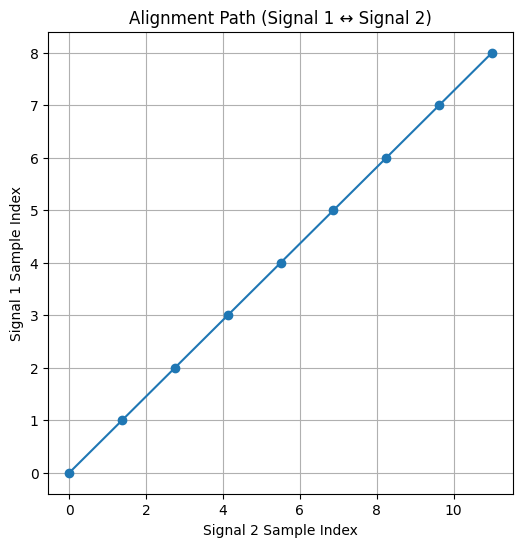

Explanation:
The alignment path is a straight line, showing a linear mapping between sample indices of Signal 1 and Signal 2.



In [ ]:
# ---------------------------------------------------------------
# (d) Plot the alignment path (mapping between samples)
# ---------------------------------------------------------------

signal1_indices = np.arange(len1)
signal2_indices = np.linspace(0, len2 - 1, len1)

plt.figure(figsize=(6, 6))
plt.plot(signal2_indices, signal1_indices, marker='o')
plt.title('Alignment Path (Signal 1 ↔ Signal 2)')
plt.xlabel('Signal 2 Sample Index')
plt.ylabel('Signal 1 Sample Index')
plt.grid(True)
plt.show()

print("Explanation:")
print("The alignment path is a straight line, showing a linear mapping between sample indices of Signal 1 and Signal 2.\n")

In [ ]:
# ---------------------------------------------------------------
# (e) Inference
# ---------------------------------------------------------------

inference = """
Linear Time Normalization (LTN) aligns the two speech signals by uniformly scaling the
time axis of the slower (longer) signal to match the length of the reference signal.
This allows both signals to be compared sample-by-sample, even though they were spoken
at different speeds. LTN assumes a constant rate difference throughout the utterance.
While it effectively aligns uniformly stretched signals, it may not handle variable-speed
segments as accurately as non-linear methods like Dynamic Time Warping (DTW).
"""
print("Inference:")
print(inference)

Inference:

Linear Time Normalization (LTN) aligns the two speech signals by uniformly scaling the
time axis of the slower (longer) signal to match the length of the reference signal.
This allows both signals to be compared sample-by-sample, even though they were spoken
at different speeds. LTN assumes a constant rate difference throughout the utterance.
While it effectively aligns uniformly stretched signals, it may not handle variable-speed
segments as accurately as non-linear methods like Dynamic Time Warping (DTW).

